In [49]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [51]:
path = '../survey_design/telescope_and_science_metrics/'

In [52]:
survey_design_dark = load(path + 'survey_design_Dark.pkl')
#survey_design_bright = load(path + 'survey_design_Grey.pkl')

In [53]:
survey_design_dark['total_survey_Informations'].keys()

dict_keys(['total_survey_time', 'total_survey_efficiency', 'total_survey_fisher_information_fnl', 'total_survey_fisher_information_Da', 'total_survey_fisher_information_H', 'total_survey_fisher_information_Mnu', 'total_survey_fisher_information_rsd', 'total_survey_information_FnP_k0.001', 'total_survey_information_FnP_k0.1', 'total_survey_information_FnP_k1', 'LBGu_efficiency', 'LBGg_efficiency', 'LBGr_efficiency'])

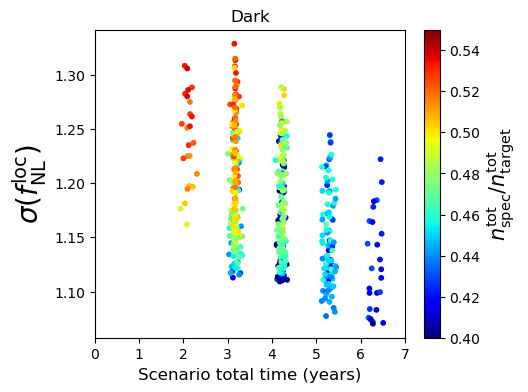

In [54]:
for survey in [survey_design_dark]:
    sigma_Da_target = 0.0006
    sigma_fnl_target = 1.1
    plt.figure(figsize=(5,4))
    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    Information_Mnu = survey['total_survey_Informations']['total_survey_fisher_information_Mnu']
    Information_rsd = survey['total_survey_Informations']['total_survey_fisher_information_rsd']
    total_time= survey['total_survey_Informations']['total_survey_time']
    total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']
    
    FoM_all = (sigma_fnl_target **2 * Information_fnl + sigma_Da_target **2 * Information_Da)
    FoM_fnl = sigma_fnl_target **2 * Information_fnl
    FoM_Da = sigma_Da_target **2 * Information_Da
    plt.title(survey['config_survey']['survey_type'])
    x = 2*np.random.random(len(total_time.flatten())) -1
    #plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  1/Information_fnl**.5,c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  1/Information_fnl**.5,c= total_survey_efficiency.flatten(), s=10, 
                label = 'Combined', cmap='jet', vmax=0.55, vmin=0.4)
    #plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  100*1/Information_rsd**.5,c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.xlabel(r'Scenario total time (years)', fontsize=12)
    cbar = plt.colorbar()
    cbar.set_label(r'$n_{\rm spec}^{\rm tot}/n_{\rm target}^{\rm tot}$', fontsize=15)
    plt.xlim(0, 7)

(8, 8, 8)


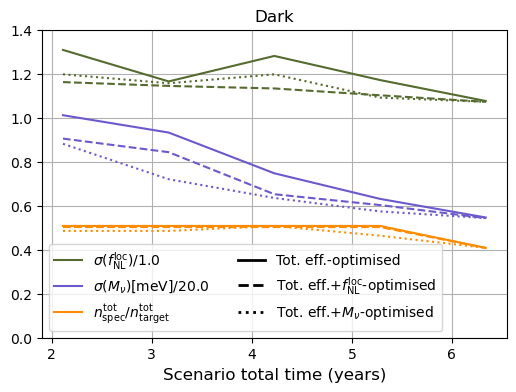

In [77]:
for survey in [ survey_design_dark,]:
    plt.figure(figsize=(6,4))
    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    Information_Mnu = survey['total_survey_Informations']['total_survey_fisher_information_Mnu']
    Information_rsd = survey['total_survey_Informations']['total_survey_fisher_information_rsd']
    print(Information_fnl.shape)
    colors = ['darkolivegreen', 'slateblue']
    Informations = [
        Information_fnl,
        #Information_Da / (100**2),
        Information_Mnu / (1000**2),
       # Information_rsd / (100**2),
    ]
    labels = [r'$\sigma(f_{\rm NL}^{\rm loc})$', 
              #r'$\sigma(\ln D_A) (\%)$', 
              r'$\sigma(M_\nu)$[meV]',
              #r'$\sigma(\ln f\sigma_8) (\%)$'
             ]
    error_base = [1, 
                #  0.07, 
                  20, 
                 # 1
                 ]
    total_time = survey['total_survey_Informations']['total_survey_time']
    #total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']
    total_survey_efficiency = survey['total_survey_Informations']['LBGg_efficiency']
    #total_survey_efficiency = (survey['total_survey_Informations']['LBGu_efficiency']+survey['total_survey_Informations']['LBGr_efficiency']+survey['total_survey_Informations']['LBGr_efficiency'])/3
    plt.title(survey['config_survey']['survey_type'])
    unique_total_time = np.unique(total_time)
    for k, info in enumerate(Informations):
        times = []
        errors = []
        efficiency = []
        coords_eff = []
        for t_survey in unique_total_time:
            mask_time = total_time.flatten() == t_survey
            error = 1 / np.sqrt(info.flatten()[mask_time])
            efficiency_ = total_survey_efficiency.flatten()[mask_time]
            best_idx = np.argmax(efficiency_)
            times.append(t_survey)
            errors.append(error[best_idx])
            efficiency.append(efficiency_[best_idx])
            flat_indices_full = np.nonzero(mask_time)[0]
            flat_idx_full = flat_indices_full[best_idx]
            shape = Information_fnl.shape
            coords_eff.append(np.unravel_index(flat_idx_full, shape))
        plt.plot(times,np.array(errors)/error_base[k], '-', color=colors[k], label=labels[k] +F'/${error_base[k]:.1f}$')
    plt.plot(times, efficiency, '-',color='darkorange', label = r'$n_{\rm spec}^{\rm tot}/n_{\rm target}^{\rm tot}$')

    def science_to_optimize(science_case_to_optimize, style, add_efficiency = False):
        if science_case_to_optimize == 'fnl':
            info_to_optimize = Information_fnl
        if science_case_to_optimize == 'mnu':
            info_to_optimize = Information_Mnu
        if science_case_to_optimize == 'both':
            info_to_optimize = Information_Mnu + 0.01*Information_fnl
        for k, info in enumerate(Informations):
            times = []
            errors = []
            efficiency = []
            coords_eff = []
            for t_survey in unique_total_time:
                mask_time = total_time.flatten() == t_survey
                error_to_optimize = 1 / np.sqrt(info_to_optimize.flatten()[mask_time])
                error = 1 / np.sqrt(info.flatten()[mask_time])
                efficiency_ = total_survey_efficiency.flatten()[mask_time]
                if add_efficiency:
                    best_idx = np.argsort(error_to_optimize**2/efficiency_)[0]   
                else:
                    best_idx = np.argsort(error_to_optimize**2)[0]  
                times.append(t_survey)
                errors.append(error[best_idx])
                efficiency.append(efficiency_[best_idx])
                flat_indices_full = np.nonzero(mask_time)[0]
                flat_idx_full = flat_indices_full[best_idx]
                shape = Information_fnl.shape
                coords_eff.append(np.unravel_index(flat_idx_full, shape))
            plt.plot(times,np.array(errors)/error_base[k], style, color=colors[k],)
        plt.plot(times, efficiency, style,color='darkorange', )
        return coords_eff

    #coords_fnl_optimal = science_to_optimize('fnl', '--')
    #coords_Mnu_optimal = science_to_optimize('mnu', ':')
    coords_fnl_eff_optimal = science_to_optimize('fnl', '--', add_efficiency=True)
    coords_Mnu_eff_optimal = science_to_optimize('mnu', ':', add_efficiency=True)

        #if k ==0: plt.plot(times, efficiency, '--',color=colors[k], label = r'$n_{\rm spec}/n_{\rm target}$')
    plt.plot([], [], '-k', lw=2, label = r'Tot. eff.-optimised')
    plt.plot([], [], '--k', lw=2,  label = r'Tot. eff.+$f^{\rm loc}_{\rm NL}$-optimised')
    plt.plot([], [], ':k',  lw=2, label = r'Tot. eff.+$M_\nu$-optimised')
    plt.legend(ncols=2)
    plt.xlabel(r'Scenario total time (years)', fontsize=12)
    plt.grid()
    #plt.ylabel(r'$\sigma$(param)/$\sigma$(ref)', fontsize=14)
    #plt.xlim(0, 7)
    plt.ylim(0., 1.4)

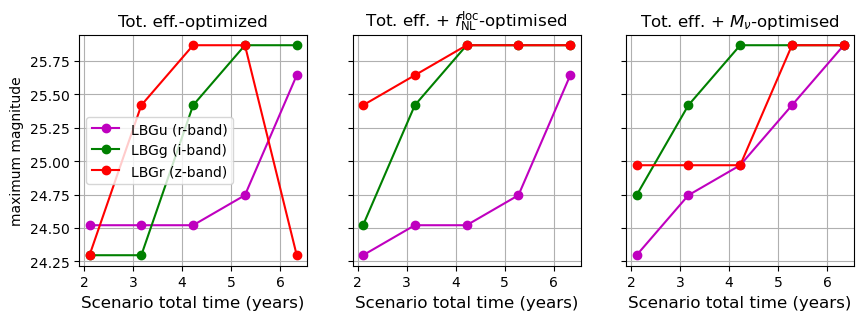

In [75]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

coords_list = [coords_eff, coords_fnl_eff_optimal, coords_Mnu_eff_optimal]
title = ['Tot. eff.-optimized', r'Tot. eff. + $f^{\rm loc}_{\rm NL}$-optimised',r'Tot. eff. + $M_\nu$-optimised']
for k, ax, coords in zip(np.arange(len(axs)), axs, coords_list):
    coords_arr = np.array(coords)
    for i, tracer in enumerate(survey_design_dark['config_survey']['tracers']):
        mag_centers = survey['config_survey'][tracer + '_mag_centers']
        ax.set_title(title[k])
        ax.plot(
            times,
            mag_centers[coords_arr[:, i]],
            ls='-', marker='o',
            color=survey['config_survey']['color'][i],
            label=tracer + ' (' + survey_design_dark['config_survey']['limiting_mag_band'][i] + '-band)'
        )
    ax.set_xlabel(r'Scenario total time (years)', fontsize=12)
    ax.grid()

axs[0].set_ylabel('maximum magnitude')
axs[0].legend()

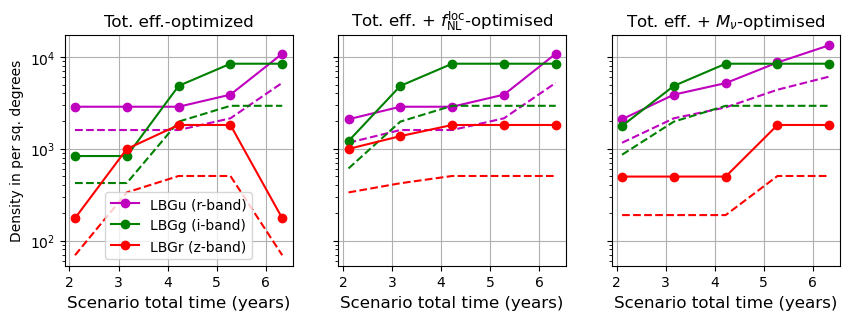

In [76]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

coords_list = [coords_eff, coords_fnl_eff_optimal, coords_Mnu_eff_optimal]
title = ['Tot. eff.-optimized', r'Tot. eff. + $f^{\rm loc}_{\rm NL}$-optimised',r'Tot. eff. + $M_\nu$-optimised']
for k, ax, coords in zip(np.arange(len(axs)), axs, coords_list):
    coords_arr = np.array(coords)
    for i, tracer in enumerate(survey_design_dark['config_survey']['tracers']):
        mag_centers = survey['config_survey'][tracer + '_spec_density']
        ax.set_title(title[k])
        #ax.plot(
         #   times,
         #   mag_centers[coords_arr[:, i]],
         #@   ls='-', marker='o',
         #   color=survey['config_survey']['color'][i],
         #   label=tracer + ' (' + survey_design_dark['config_survey']['limiting_mag_band'][i] + '-band)'
        #)
        mag_centers = survey['config_survey'][tracer + '_target_density']
        ax.set_title(title[k])
        ax.plot(
            times,
            mag_centers[coords_arr[:, i]],
            ls='-', marker='o',
            label=tracer + ' (' + survey_design_dark['config_survey']['limiting_mag_band'][i] + '-band)',
            color=survey['config_survey']['color'][i],
        )
        mag_centers = survey['config_survey'][tracer + '_spec_density']
        ax.set_title(title[k])
        ax.plot(
            times,
            mag_centers[coords_arr[:, i]],
            ls='--', marker='',
            #label=tracer + ' (' + survey_design_dark['config_survey']['limiting_mag_band'][i] + '-band)',
            color=survey['config_survey']['color'][i],
        )
    ax.set_xlabel(r'Scenario total time (years)', fontsize=12)
    ax.grid()
    ax.set_yscale('log')

axs[0].set_ylabel('Density in per sq. degrees')
axs[0].legend()

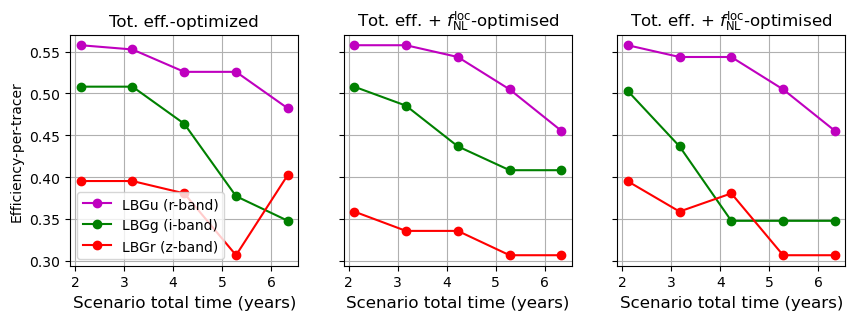

In [73]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

coords_list = [coords_eff, coords_fnl_eff_optimal, coords_Mnu_eff_optimal]
title = ['Tot. eff.-optimized', r'Tot. eff. + $f^{\rm loc}_{\rm NL}$-optimised',r'Tot. eff. + $f^{\rm loc}_{\rm NL}$-optimised']
for k, ax, coords in zip(np.arange(len(axs)), axs, coords_list):
    coords_arr = np.array(coords)
    for i, tracer in enumerate(survey_design_dark['config_survey']['tracers']):
        mag_centers = survey['config_survey'][tracer + '_spec_density']
        ax.set_title(title[k])

        mag_centers = survey['config_survey'][tracer + '_spec_density']/survey['config_survey'][tracer + '_target_density']
        ax.set_title(title[k])
        ax.plot(
            times,
            mag_centers[coords_arr[:, i]],
            label=tracer + ' (' + survey_design_dark['config_survey']['limiting_mag_band'][i] + '-band)',
            ls='-', marker='o',
            color=survey['config_survey']['color'][i],
        )
    ax.set_xlabel(r'Scenario total time (years)', fontsize=12)
    ax.grid()
    #ax.set_yscale('log')

axs[0].set_ylabel('Efficiency-per-tracer')
axs[0].legend()